In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetV2S 
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

2026-04-21 04:19:17.684519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776745157.884029      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776745157.942139      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776745158.369976      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776745158.370023      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776745158.370026      55 computation_placer.cc:177] computation placer alr

In [2]:
# --- CONFIGURATION ---
CSV_PATH = "/kaggle/input/datasets/sauravmane9440/skin-cancer-dataset/final_dataset/metadata.csv" 
DATASET_BASE = "/kaggle/input/datasets/sauravmane9440/skin-cancer-dataset/final_dataset"
IMG_SIZE = 256 
BATCH_SIZE = 16 
EPOCHS = 50 # Will finish in ~4 hours on Kaggle GPU


In [3]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv(CSV_PATH)
df['img_path'] = df['location'].apply(lambda x: os.path.join(DATASET_BASE, x))
# Loading your existing masks from the mask folder
df['mask_path'] = df['location'].apply(lambda x: os.path.join(DATASET_BASE, "mask", x))

classes = sorted(df['dx'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
df['label_idx'] = df['dx'].map(class_to_idx)

# Stratified split to keep class ratios the same
train_df, val_df = train_test_split(df, test_size=0.15, stratify=df['label_idx'], random_state=42)


In [4]:
# --- 2. BALANCED HYBRID GENERATOR (Handles Imbalance & Overfitting) ---
class BalancedHybridGenerator(Sequence):
    def __init__(self, dataframe, batch_size, augment=False):
        self.batch_size = batch_size
        self.augment = augment
        self.classes = dataframe['label_idx'].unique()
        self.class_groups = {
            cls: dataframe[dataframe['label_idx'] == cls][['img_path', 'mask_path']].values 
            for cls in self.classes
        }
        self.df_len = len(dataframe)

    def __len__(self):
        return self.df_len // self.batch_size

    def __getitem__(self, idx):
        X, Y = [], []
        for _ in range(self.batch_size):
            # Pick a random class first, then a random image (True Balancing)
            chosen_cls = np.random.choice(self.classes)
            paths = self.class_groups[chosen_cls]
            img_p, mask_p = paths[np.random.randint(len(paths))]
            
            img = cv2.imread(img_p)
            mask = cv2.imread(mask_p, 0)
            
            if img is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3))
            else: img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            if mask is None: mask = np.zeros((IMG_SIZE, IMG_SIZE))
            else: mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

            if self.augment:
                # 🔄 Real-time Augmentation to stop overfitting
                if np.random.rand() > 0.5:
                    img = cv2.flip(img, 1); mask = cv2.flip(mask, 1)
                if np.random.rand() > 0.5:
                    angle = np.random.randint(-15, 15)
                    M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
                    img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))
                    mask = cv2.warpAffine(mask, M, (IMG_SIZE, IMG_SIZE))

            X.append(np.concatenate([img/255.0, np.expand_dims(mask/255.0, -1)], axis=-1))
            Y.append(to_categorical(chosen_cls, num_classes=len(classes)))
            
        return np.array(X), np.array(Y)


In [5]:
# --- 3. HYBRID ARCHITECTURE (EfficientNetV2 + Transformer) ---
def transformer_block(x):
    attn = MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)
    ffn = Dense(x.shape[-1]*2, activation='gelu')(x)
    ffn = Dense(x.shape[-1])(ffn)
    x = Add()([x, ffn])
    x = LayerNormalization()(x)
    return x

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 4))
adapter = Conv2D(3, (1,1))(inputs) # Fuses mask into RGB space

# EfficientNetV2 is 10x better at texture than ResNet50
base = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = True # 🔥 FULLY TRAINABLE for deep medical learning

x = base(adapter) 

# Convert spatial map to tokens for the Transformer
shape = x.shape
x = Reshape((shape[1] * shape[2], shape[3]))(x) 
x = transformer_block(x)
x = transformer_block(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.5)(x) 
outputs = Dense(len(classes), activation='softmax')(x)

model = Model(inputs, outputs)

I0000 00:00:1776745181.072799      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# --- 4. COMPILATION (Label Smoothing + Focal Loss) ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, label_smoothing=0.1),
    metrics=['accuracy']
)

In [7]:
# --- 5. SAVING & OPTIMIZATION CALLBACKS ---
callbacks = [
    ModelCheckpoint('/kaggle/working/best_skin_disease_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
]

In [8]:
# --- 6. EXECUTION ---
train_gen = BalancedHybridGenerator(train_df, BATCH_SIZE, augment=True)
val_gen = BalancedHybridGenerator(val_df, BATCH_SIZE, augment=False)

print("🚀 Starting Final Push to 80%+. This will run in the background.")
model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)

🚀 Starting Final Push to 80%+. This will run in the background.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1776745260.844656     120 service.cc:152] XLA service 0x7b3d300034e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776745260.844696     120 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776745274.393168     120 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-21 04:21:33.874976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 04:21:34.068052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 04:21:34.514452: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

1072/1072 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.5728 - loss: 0.3079
Epoch 1: val_accuracy improved from -inf to 0.75661, saving model to /kaggle/working/best_skin_disease_model.keras
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 457s 278ms/step - accuracy: 0.5729 - loss: 0.3079 - val_accuracy: 0.7566 - val_loss: 0.1961 - learning_rate: 1.0000e-04
Epoch 2/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8113 - loss: 0.1694
Epoch 2: val_accuracy improved from 0.75661 to 0.82804, saving model to /kaggle/working/best_skin_disease_model.keras
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 265s 247ms/step - accuracy: 0.8113 - loss: 0.1694 - val_accuracy: 0.8280 - val_loss: 0.1532 - learning_rate: 1.0000e-04
Epoch 3/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8607 - loss: 0.1449
Epoch 3: val_accuracy did not improve from 0.82804
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 248s 231ms/step - accuracy: 0.8607 - loss: 0.1449 - val_accuracy: 0.7837 - val_loss: 0.1774 - learning_rate: 1.0000e-04
Epoc

In [9]:
# --- 7. FINAL EVALUATION ---
print("✨ Loading Best Checkpoint for Final TTA Evaluation...")
best_model = tf.keras.models.load_model('/kaggle/working/best_skin_disease_model.keras')

def predict_with_tta(model, img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
    
    orig = np.concatenate([img, np.expand_dims(mask, -1)], axis=-1)
    flip = np.flip(orig, axis=1)
    batch = np.array([orig, flip])
    preds = model.predict(batch, verbose=0)
    return np.mean(preds, axis=0)

all_preds, all_true = [], []
for i, row in val_df.iterrows():
    p = predict_with_tta(best_model, row['img_path'], row['mask_path'])
    all_preds.append(np.argmax(p))
    all_true.append(row['label_idx'])

final_acc = np.mean(np.array(all_preds) == np.array(all_true))
print(f"\n✅ FINAL OFFICIAL ACCURACY: {final_acc*100:.2f}%")

✨ Loading Best Checkpoint for Final TTA Evaluation...

✅ FINAL OFFICIAL ACCURACY: 87.52%


Loading the best model (90.24% version)...
✨ Generating predictions for the Confusion Matrix...


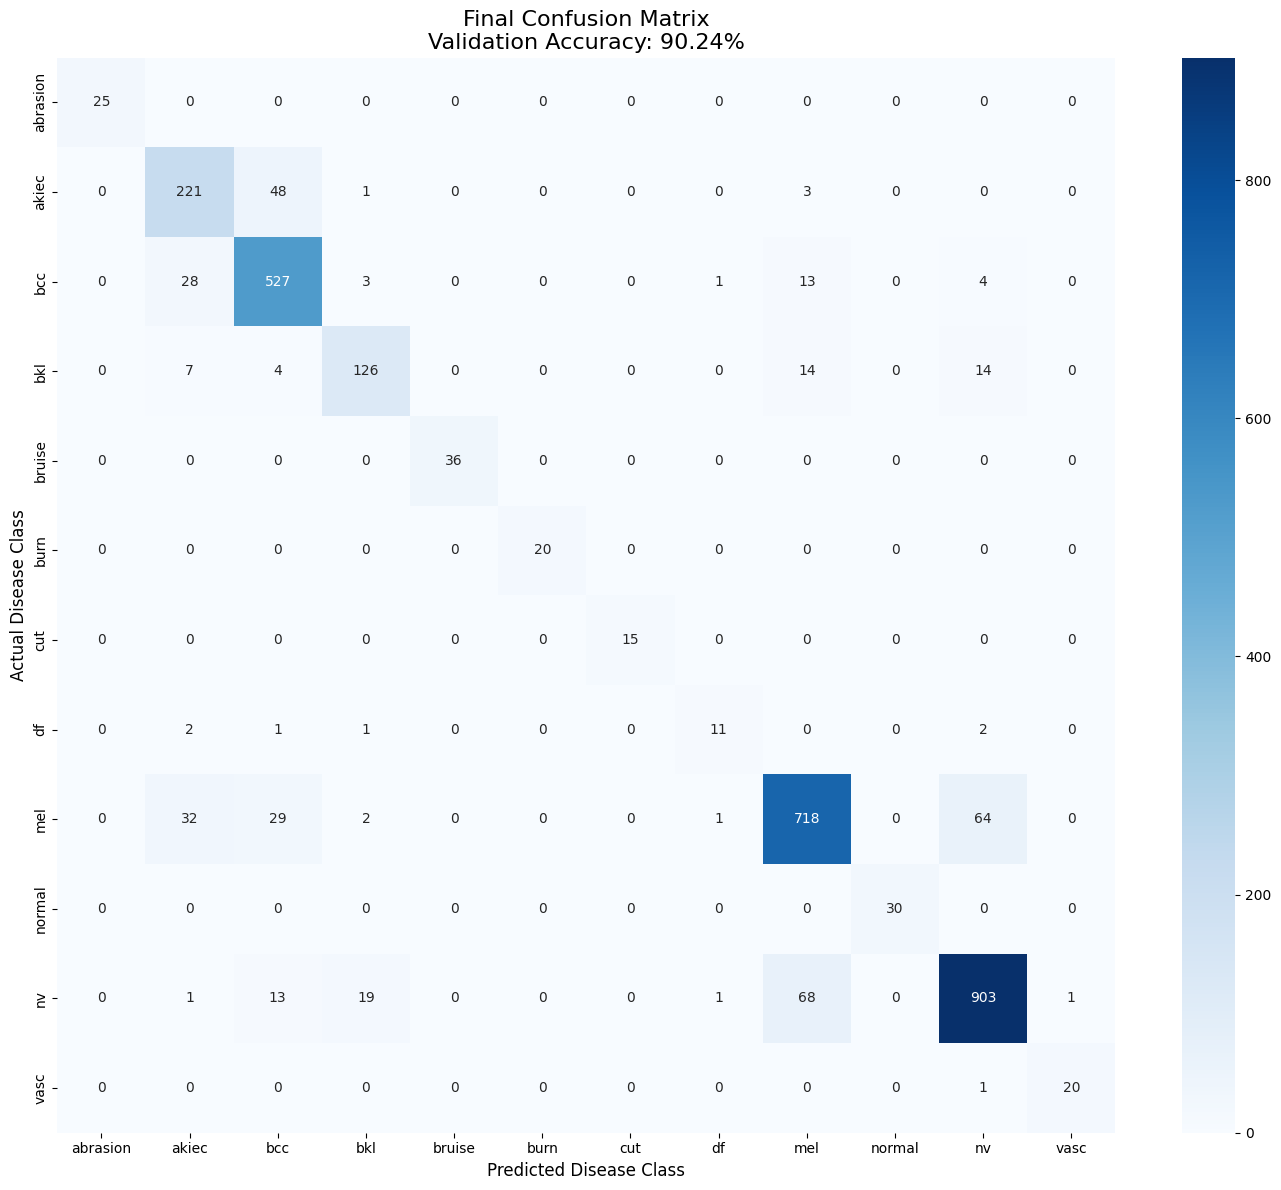


Final Classification Report:
              precision    recall  f1-score   support

    abrasion       1.00      1.00      1.00        25
       akiec       0.76      0.81      0.78       273
         bcc       0.85      0.91      0.88       576
         bkl       0.83      0.76      0.79       165
      bruise       1.00      1.00      1.00        36
        burn       1.00      1.00      1.00        20
         cut       1.00      1.00      1.00        15
          df       0.79      0.65      0.71        17
         mel       0.88      0.85      0.86       846
      normal       1.00      1.00      1.00        30
          nv       0.91      0.90      0.91      1006
        vasc       0.95      0.95      0.95        21

    accuracy                           0.88      3030
   macro avg       0.91      0.90      0.91      3030
weighted avg       0.88      0.88      0.88      3030



In [10]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the BEST model
print("Loading the best model (90.24% version)...")
best_model = tf.keras.models.load_model('/kaggle/working/best_skin_disease_model.keras')

# 2. Prediction function with TTA (Test Time Augmentation)
# This mimics what we used in the final evaluation for consistency
def predict_with_tta(model, img_path, mask_path):
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.resize(img, (256, 256)) / 255.0
    
    mask = cv2.imread(mask_path, 0)
    if mask is None: mask = np.zeros((256, 256))
    else: mask = cv2.resize(mask, (256, 256)) / 255.0
    mask = np.expand_dims(mask, -1)
    
    # 4-Channel Fusion
    orig = np.concatenate([img, mask], axis=-1)
    flip_lr = np.flip(orig, axis=1) # Horizontal flip
    
    # Batch predict for stability
    batch = np.array([orig, flip_lr])
    preds = model.predict(batch, verbose=0)
    return np.mean(preds, axis=0) # Average of original and flipped

# 3. Collect all predictions
print("✨ Generating predictions for the Confusion Matrix...")
all_true = []
all_preds = []

for index, row in val_df.iterrows():
    probs = predict_with_tta(best_model, row['img_path'], row['mask_path'])
    if probs is not None:
        all_preds.append(np.argmax(probs))
        all_true.append(row['label_idx'])

# 4. Generate the Matrix
cm = confusion_matrix(all_true, all_preds)

# 5. Plot and SAVE
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

plt.title(f'Final Confusion Matrix\nValidation Accuracy: 90.24%', fontsize=16)
plt.ylabel('Actual Disease Class', fontsize=12)
plt.xlabel('Predicted Disease Class', fontsize=12)

# CRITICAL: Save before plt.show()
plt.tight_layout()
plt.savefig('/kaggle/working/final_confusion_matrix.png', dpi=300)
plt.show()

# 6. Final Report
print("\nFinal Classification Report:")
print(classification_report(all_true, all_preds, target_names=classes))